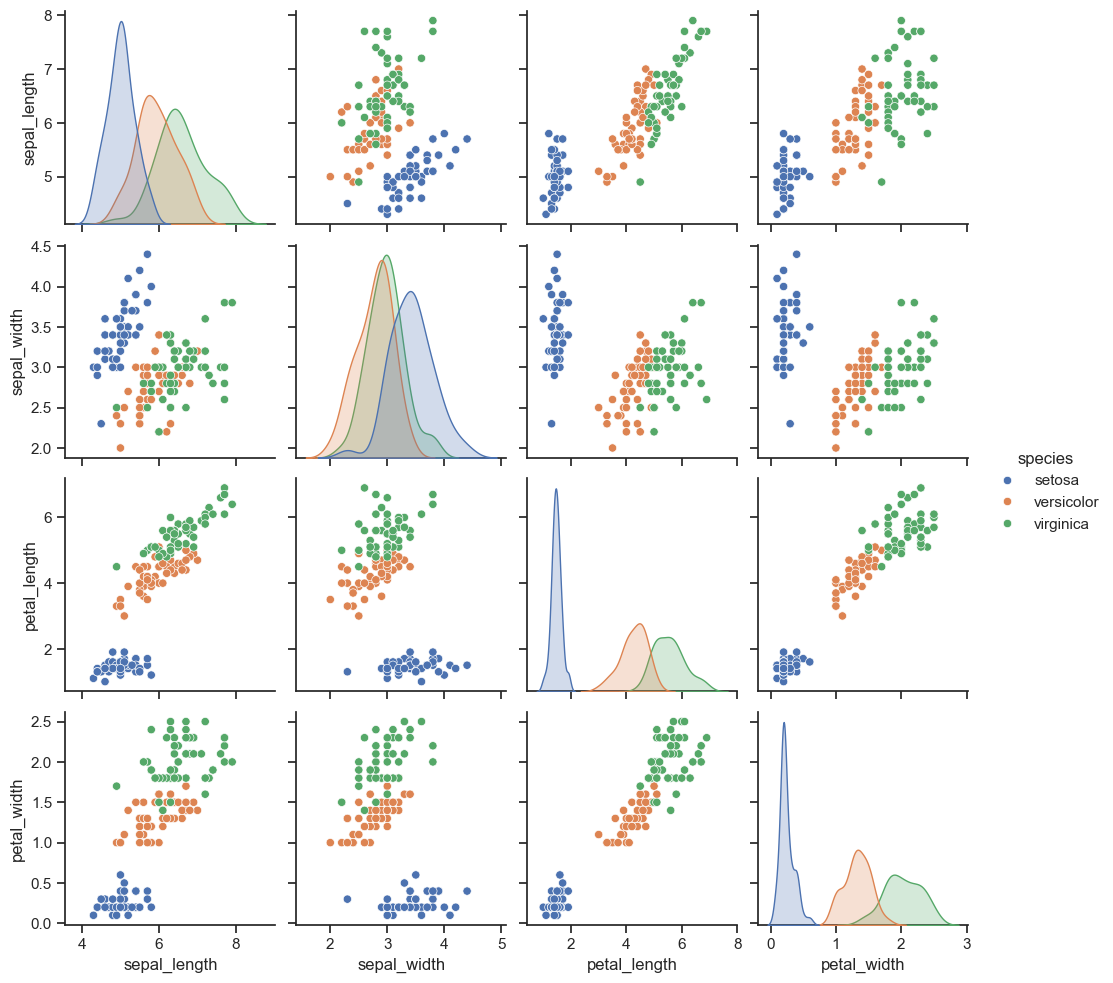

In [19]:
# Importamos librerias para visualizacion de datos y tecnicas de reduccion de dimension
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Establecemos el tema estetico de las graficas
sns.set_theme(style="ticks")

# Cargamos el clasico conjunto de datos de flores Iris
df = sns.load_dataset("iris")

# Graficamos diagramas de dispersion por pares entre todas las variables coloreando por especie
sns.pairplot(df, hue="species")


<Axes: xlabel='petal_length', ylabel='sepal_length'>

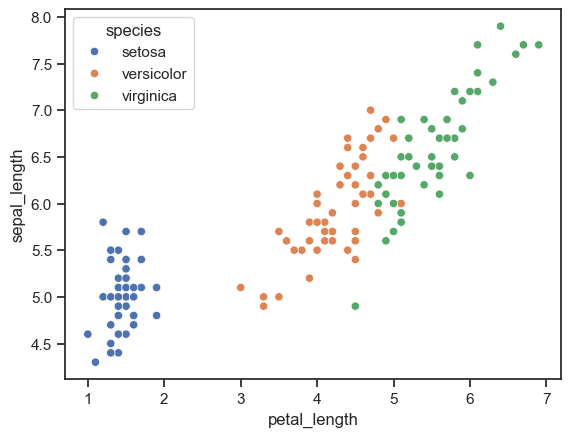

In [7]:
# Graficamos la dispersion entre longitud de petalo y longitud de sepalo diferenciando por especie
sns.scatterplot(data=df, x='petal_length', y='sepal_length', hue='species')


In [8]:
# Seleccionamos dos columnas y contamos el numero de observaciones disponibles por cada especie
df = sns.load_dataset("iris")[['sepal_length', 'species']]
df.groupby('species').count()


,sepal_length
species,
setosa,50
versicolor,50
virginica,50


## Fase de entrenamiento con 150 datos

Típicamente se usa menos información. Al ser tu primer acercamiento a los algoritmos de ML usaremos toda la información. Idealmente se entrena un modelo con 80 o 70% de la información disponible y nunca con el 100%, como en este caso.

In [42]:
# Estimamos el modelo de Analisis Discriminante Lineal (LDA) sobre los datos completos
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Cargamos las caracteristicas numericas y las etiquetas de especie desde scikit-learn
iris = datasets.load_iris()

X = iris.data # Matriz de 4 variables de medicion floral
y = iris.target # Clases numericas correspondientes a cada especie (0, 1, 2)
target_names = iris.target_names # Nombres de las especies: setosa, versicolor, virginica

# Aplicamos PCA con 2 componentes como tecnica de reduccion no supervisada
pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)

# Aplicamos LDA con 2 componentes como tecnica de reduccion y clasificacion supervisada
lda = LinearDiscriminantAnalysis(n_components=2)
X_r2 = lda.fit(X, y).transform(X)


In [43]:
# Obtenemos las predicciones del modelo LDA sobre los datos observados
predictions = lda.predict(X)

# Calculamos la matriz de confusion comparando clases reales con predichas
cm = confusion_matrix(y, predictions)


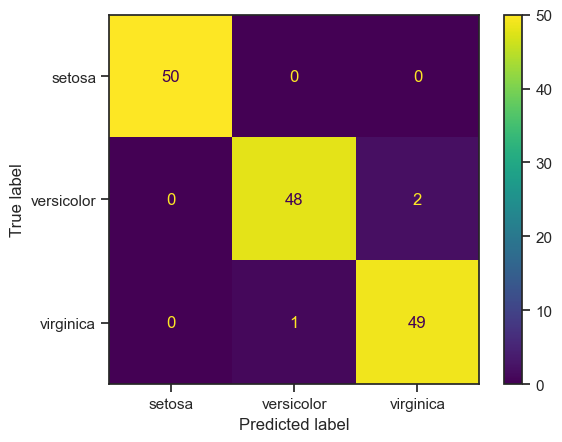

In [45]:
# Graficamos la matriz de confusion con etiquetas legibles de las especies
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_names)
disp.plot()


# Fase de entrenamiento y pruebas 70/30

In [80]:
# Dividimos los datos en conjunto de entrenamiento (70%) y conjunto de prueba (30%)
from sklearn.model_selection import train_test_split

# Cargamos los datos en formato DataFrame de pandas
iris = datasets.load_iris(as_frame=True)
X, y = iris['data'], iris['target']

# Realizamos la particion aleatoria fijando la semilla con random_state=7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=7)


In [88]:
# Entrenamos el modelo LDA con los datos de entrenamiento y transformamos las dimensiones
lda = LinearDiscriminantAnalysis(n_components=2)
lda_model = lda.fit(X_train, y_train).transform(X_train)


In [89]:
# Realizamos las predicciones sobre el conjunto de prueba para evaluar generalizacion
predictions = lda.predict(X_test)

# Calculamos la matriz de confusion del conjunto de prueba
cm = confusion_matrix(y_test, predictions)


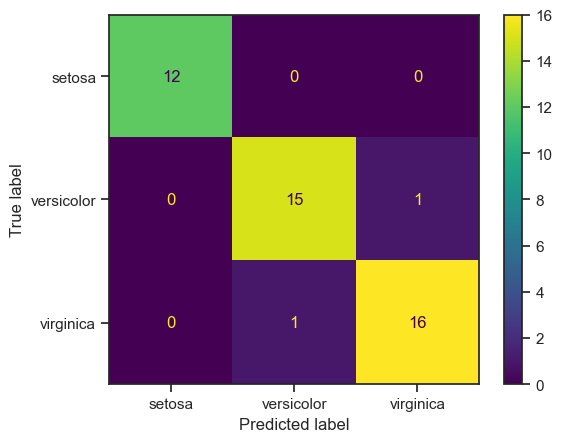

In [90]:
# Mostramos graficamente la matriz de confusion obtenida sobre los datos de prueba
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_names)
disp.plot()
